# 检查 PyTorch / MPS (Apple 芯片加速)

In [1]:
import torch, platform
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available (Apple GPU):", torch.backends.mps.is_available())
device = "mps" if torch.backends.mps.is_available() else "cpu"
device


Python: 3.13.2
PyTorch: 2.7.1
CUDA available: False
MPS available (Apple GPU): True


'mps'

# 先用预训练模型跑个推理

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

res = model.predict(
    source="/Users/taitinglu/Desktop/IMG2SCH/Yolo/sample.jpg",
    device=device,
    save=True,
    conf=0.25,
    project="/Users/taitinglu/Desktop/IMG2SCH/Yolo/output",  # 自定义输出根目录
    name="."  # 子目录名
)



image 1/1 /Users/taitinglu/Desktop/IMG2SCH/Yolo/sample.jpg: 448x640 4 persons, 26.6ms
Speed: 1.8ms preprocess, 26.6ms inference, 8.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /Users/taitinglu/Desktop/IMG2SCH/Yolo/output2


# 案例学习

## 准备数据集

In [33]:
from PIL import Image, ImageDraw
from pathlib import Path
import random
import zipfile

# ================== 可配置参数 ==================
ROOT = Path("/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset")
TOTAL_IMAGES = 2000          # 总张数（可改）
VAL_RATIO = 0.2              # 验证集占比（0.2 -> 20%）
IMG_SIZE = (800, 600)        # 画布尺寸（可改）
OBJ_NUM_RANGE = (5, 10)      # 每图内目标数量范围（可改）
CLASSES = ["IC", "R", "C", "PowerSymbol", "Connector", "JunctionDot"]
SAVE_ZIP = False              # 生成完是否打包 zip
RANDOM_SEED = 42             # 固定随机种子以复现（可改/可关）
# =================================================

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

# 目录
for sub in ["images/train","images/val","labels/train","labels/val"]:
    (ROOT / sub).mkdir(parents=True, exist_ok=True)

def make_dummy_image(path_img, path_label, num_objs=5, img_size=IMG_SIZE):
    img = Image.new("RGB", img_size, "white")
    draw = ImageDraw.Draw(img)
    W, H = img_size
    lines = []

    for _ in range(num_objs):
        cls_id = random.randint(0, len(CLASSES) - 1)
        w = random.randint(40, 100)
        h = random.randint(30, 80)
        x1 = random.randint(0, W - w)
        y1 = random.randint(0, H - h)
        x2 = x1 + w
        y2 = y1 + h

        # 画矩形框（仅可视化，训练用的是下方的 txt）
        color = tuple(random.randint(0, 200) for _ in range(3))
        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)

        # YOLO txt：class xc yc w h (归一化 0~1)
        xc = (x1 + x2) / 2 / W
        yc = (y1 + y2) / 2 / H
        ww = (x2 - x1) / W
        hh = (y2 - y1) / H
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {ww:.6f} {hh:.6f}")

    img.save(path_img, quality=92)
    path_label.write_text("\n".join(lines), encoding="utf-8")

# 计算数量
n_val = int(TOTAL_IMAGES * VAL_RATIO)
n_train = TOTAL_IMAGES - n_val

# 生成训练集
for i in range(n_train):
    make_dummy_image(
        ROOT / "images/train" / f"train_{i:04d}.jpg",
        ROOT / "labels/train" / f"train_{i:04d}.txt",
        num_objs=random.randint(*OBJ_NUM_RANGE)
    )
# 生成验证集
for i in range(n_val):
    make_dummy_image(
        ROOT / "images/val" / f"val_{i:04d}.jpg",
        ROOT / "labels/val" / f"val_{i:04d}.txt",
        num_objs=random.randint(*OBJ_NUM_RANGE)
    )

# 写 data.yaml
(ROOT / "data.yaml").write_text(
    f"""path: {ROOT}
train: images/train
val: images/val
names: {CLASSES}
""",
    encoding="utf-8"
)

print(f"✅ Dummy 数据集已生成：{ROOT}")
print(f"   训练集：{n_train} 张，验证集：{n_val} 张")



✅ Dummy 数据集已生成：/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset
   训练集：1600 张，验证集：400 张


## Label 数据显示

In [28]:
from PIL import Image, ImageDraw
from pathlib import Path

def draw_yolo_labels(image_path, label_path, class_names=None, save_path=None):
    """
    显示 YOLO txt 标注框
    image_path: 图片路径
    label_path: 同名的 YOLO txt 标签路径
    class_names: 类别名列表（可选）
    save_path: 保存路径（可选），不传则直接显示
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    draw = ImageDraw.Draw(img)

    if not Path(label_path).exists():
        print(f"⚠️ 找不到标签文件：{label_path}")
        return img

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            # 转成像素坐标
            x1 = (xc - w / 2) * W
            y1 = (yc - h / 2) * H
            x2 = (xc + w / 2) * W
            y2 = (yc + h / 2) * H
            color = "red"
            draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
            label_text = str(cls_id) if class_names is None else class_names[cls_id]
            draw.text((x1, y1 - 10), label_text, fill=color)

    if save_path:
        img.save(save_path)
        print(f"✅ 已保存可视化图片到: {save_path}")
    else:
        img.show()
    return img


✅ 已保存可视化图片到: /Users/taitinglu/Desktop/IMG2SCH/Yolo/vis_train_0001.jpg


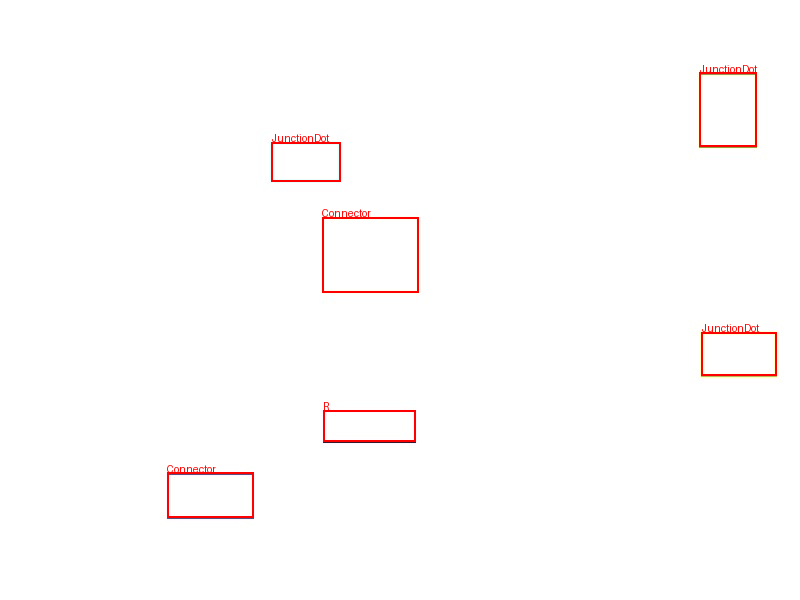

In [34]:
class_names = ["IC", "R", "C", "PowerSymbol", "Connector", "JunctionDot"]

draw_yolo_labels(
    image_path="/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/images/train/train_0001.jpg",
    label_path="/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/labels/train/train_0001.txt",
    class_names=class_names,
    save_path="/Users/taitinglu/Desktop/IMG2SCH/Yolo/vis_train_0001.jpg"
)


# 训练模型

In [35]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # 也可换 s/m/l/x
model.train(
    data="/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/data.yaml",
    imgsz=1024,
    epochs=10,
    batch=8,
    workers=2,
    device=device,
    project="/Users/taitinglu/Desktop/IMG2SCH/Yolo/output",
    name="symbol_v1"
)


Ultralytics 8.3.176 🚀 Python-3.13.2 torch-2.7.1 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=symbol_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

train: Scanning /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/labels/train... 1600 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1600/1600 [00:00<00:00, 7473.11it/s]

train: New cache created: /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/labels/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 631.0±363.1 MB/s, size: 14.2 KB)



val: Scanning /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/labels/val... 400 images, 0 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<00:00, 7530.57it/s]

val: New cache created: /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/labels/val.cache


...

WARNING ⚠️ NMS time limit 2.800s exceeded


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  24%|██▍       | 6/25 [00:36<01:39,  5.23s/it]

WARNING ⚠️ NMS time limit 2.800s exceeded


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  28%|██▊       | 7/25 [00:44<01:54,  6.38s/it]


KeyboardInterrupt: 

In [22]:
# 最优权重在这里：
best = "/Users/taitinglu/Desktop/IMG2SCH/Yolo/output/symbol_v12/weights/best.pt"

# 评估验证集
!yolo detect val model="{best}" data="/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/data.yaml" device={device}


Ultralytics 8.3.176 🚀 Python-3.13.2 torch-2.7.1 MPS (Apple M3)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 479.7±189.1 MB/s, size: 12.3 KB)
val: Scanning /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/labels/
                 Class     Images  Instances      Box(P          R      mAP50  mWARNING ⚠️ NMS time limit 2.100s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all          2         12     0.0423      0.567      0.264      0.244
                    IC          1          1          0          0          0          0
                     R          1          1    0.00513          1     0.0153     0.0138
                     C          1          1     0.0625          1      0.332      0.332
           PowerSymbol          2          2     0.0455        0.5      0.507      0.456
             Connector          2          2 

In [25]:
from ultralytics import YOLO

model = YOLO("/Users/taitinglu/Desktop/IMG2SCH/Yolo/output/symbol_v12/weights/best.pt")
results = model.predict(
    source="/Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/images/val",
    conf=0.25,
    save=True,
    show_labels=True,     # ✅ 显示类别标签
    show_conf=True,       # ✅ 显示置信度
    project="/Users/taitinglu/Desktop/IMG2SCH/Yolo/output",
    name="pred_symbol_labeled",
    exist_ok=True
)



image 1/2 /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/images/val/val_000.jpg: 768x1024 (no detections), 93.5ms
image 2/2 /Users/taitinglu/Desktop/IMG2SCH/Yolo/symbol_dummy_dataset/images/val/val_001.jpg: 768x1024 (no detections), 78.9ms
Speed: 3.2ms preprocess, 86.2ms inference, 0.4ms postprocess per image at shape (1, 3, 768, 1024)
Results saved to /Users/taitinglu/Desktop/IMG2SCH/Yolo/output/pred_symbol_labeled
